# Notebook 2.0 — Modelação e Treino
## Churn Prediction | ISCAC 2025/2026
### CRISP-DM: Fase de Modelação (M3)

**Dataset:** Telco Customer Churn — 7043 registos  
**Variável alvo:** `Churn` (0/1) — desequilíbrio ~26.5%  
**Objetivo SMART:** F1-Score ≥ 0.80 na classe Churn

---

In [1]:
# ─── Importações e Configurações Globais ─────────────────────
# Semana 8 | CRISP-DM: Modeling
# Justificação: centralizar todas as importações no início do notebook

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
# xgboost importado na Aula 17 (requer: brew install libomp no macOS)

# Criar pasta de output (Kaggle: /kaggle/working/reports/figures/)
os.makedirs('reports/figures', exist_ok=True)

# Configuração global de gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ Bibliotecas carregadas com sucesso.')
print(f'   pandas {pd.__version__} | numpy {np.__version__} | sklearn OK | imblearn OK')
print(f'   Output: {os.path.abspath("reports/figures")}')

✅ Bibliotecas carregadas com sucesso.
   pandas 2.3.3 | numpy 2.0.2 | sklearn OK | imblearn OK
   Output: /kaggle/working/reports/figures


---
## Aula 15 — 25-03-2026
### Metodologia de Avaliação e Partição de Dados

**Objectivo:** Preparar os dados para modelação — encoding, divisão treino/teste e aplicação de SMOTE.

In [2]:
# ─── Carregamento do Dataset ──────────────────────────────────
# Semana 8 | CRISP-DM: Modeling
# Justificação: carregar o dataset processado em M2

# Auto-detectar qualquer CSV disponível no Kaggle input
kaggle_matches = glob.glob('/kaggle/input/**/*.csv', recursive=True)

if kaggle_matches:
    path = kaggle_matches[0]
    df_final = pd.read_csv(path)
    print(f'📂 Dataset carregado do Kaggle: {path}')
elif os.path.exists('data/processed/churn_dataset_processed.csv'):
    df_final = pd.read_csv('data/processed/churn_dataset_processed.csv')
    print('📂 Dataset carregado localmente.')
else:
    raise FileNotFoundError('Nenhum CSV encontrado. Adiciona o dataset via "+Add Input" no Kaggle.')

print(f'\n✅ Shape: {df_final.shape}  →  {df_final.shape[0]} registos, {df_final.shape[1]} colunas')
print(f'\nColunas: {list(df_final.columns)}')
df_final.head(3)

📂 Dataset carregado do Kaggle: /kaggle/input/datasets/joscabeas/telco-churn-processed/telco_churn_processed (1).csv

✅ Shape: (7043, 24)  →  7043 registos, 24 colunas

Colunas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn', 'TenureCohort', 'TotalServices', 'LTV_Estatico', 'ChargesPerService', 'RiskScore']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TenureCohort,TotalServices,LTV_Estatico,ChargesPerService,RiskScore
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,0,Early,1,29.85,14.92,5
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,0,Mature,3,1936.30,14.24,2
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,1,Early,3,107.70,13.46,5


In [3]:
# ─── Encoding das Variáveis Categóricas ──────────────────────
# Semana 8 | CRISP-DM: Data Preparation (complemento ao M2)
# Justificação: SMOTE e sklearn exigem colunas numéricas;
#               aplicamos LabelEncoder nas binárias e get_dummies nas nominais

df_enc = df_final.copy()

# Binárias Yes/No → 0/1
bin_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in bin_cols:
    df_enc[col] = df_enc[col].map({'Yes': 1, 'No': 0})

# gender → 0/1
df_enc['gender'] = df_enc['gender'].map({'Male': 1, 'Female': 0})

# Nominais com 3+ categorias → get_dummies (drop_first evita multicolinearidade)
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod', 'TenureCohort']
df_enc = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)

# Verificação: não devem restar colunas string
str_cols = df_enc.select_dtypes(include='object').columns.tolist()
assert len(str_cols) == 0, f'❌ Ainda há colunas string: {str_cols}'
assert df_enc.isnull().sum().sum() == 0, '❌ Existem valores nulos após encoding'

print(f'✅ Encoding completo: {df_enc.shape[1]} colunas | todos os tipos numéricos')
print(f'   Tipos: {df_enc.dtypes.value_counts().to_dict()}')
print(f'\n📌 Insight: todas as variáveis categóricas convertidas para numérico — pronto para SMOTE e sklearn.')
print(f'🔧 Próximo passo: separar X e y, dividir treino/teste.')

✅ Encoding completo: 37 colunas | todos os tipos numéricos
   Tipos: {dtype('bool'): 24, dtype('int64'): 10, dtype('float64'): 3}

📌 Insight: todas as variáveis categóricas convertidas para numérico — pronto para SMOTE e sklearn.
🔧 Próximo passo: separar X e y, dividir treino/teste.


In [4]:
# ─── Separação X/y + Divisão Estratificada Treino/Teste ──────
# Semana 8 | CRISP-DM: Modeling
# Justificação: stratify=y preserva a proporção real de classes (~26.5% churn)
#               em ambas as partições — essencial para avaliação realista

X = df_enc.drop('Churn', axis=1)
y = df_enc['Churn']

print(f'Features (X): {X.shape}  |  Alvo (y): {y.shape}')
print(f'Distribuição real: {dict(y.value_counts())} → {y.mean()*100:.1f}% churn')

# Divisão estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,       # mantém proporção de classes
    random_state=42   # reprodutibilidade
)

print(f'\n✅ Divisão estratificada concluída:')
print(f'   Treino: {X_train.shape[0]} registos | Teste: {X_test.shape[0]} registos')
print(f'   Distribuição treino: {dict(y_train.value_counts())} → {y_train.mean()*100:.1f}% churn')
print(f'   Distribuição teste:  {dict(y_test.value_counts())} → {y_test.mean()*100:.1f}% churn')
print(f'\n📌 Insight: proporção de churn mantida em ambas as partições — divisão estratificada correcta.')
print(f'🔧 Próximo passo: aplicar SMOTE apenas no treino.')

Features (X): (7043, 36)  |  Alvo (y): (7043,)
Distribuição real: {0: np.int64(5174), 1: np.int64(1869)} → 26.5% churn

✅ Divisão estratificada concluída:
   Treino: 5634 registos | Teste: 1409 registos
   Distribuição treino: {0: np.int64(4139), 1: np.int64(1495)} → 26.5% churn
   Distribuição teste:  {0: np.int64(1035), 1: np.int64(374)} → 26.5% churn

📌 Insight: proporção de churn mantida em ambas as partições — divisão estratificada correcta.
🔧 Próximo passo: aplicar SMOTE apenas no treino.


### Justificação da Divisão 80/20 e do SMOTE

#### Divisão 80/20 com estratificação
- **80% treino** (~5634 registos): suficiente para aprendizagem, incluindo após *oversampling*.
- **20% teste** (~1409 registos): amostra representativa para avaliação final.
- `stratify=y`: ambas as partições mantêm ~26.5% de *churn*.
- `random_state=42`: reprodutibilidade total.

#### SMOTE — apenas no treino
O dataset tem **desequilíbrio de classes** (~73.5% vs ~26.5%). O SMOTE cria exemplos sintéticos da classe minoritária para equilibrar o treino.

> ⚠️ **Regra crítica:** SMOTE aplicado **exclusivamente no treino**. No teste, constituiria *data leakage* — métricas inflacionadas, desempenho real mascarado.

Distribuição antes do SMOTE (treino):
   Classe 0 (Não-churn): 4139
   Classe 1 (Churn):     1495

Distribuição depois do SMOTE (treino):
   Classe 0 (Não-churn): 4139
   Classe 1 (Churn):     4139

✅ Resumo:
   X_train_bal: (8278, 36)  |  X_test: (1409, 36)
   Distribuição teste (real, sem SMOTE): {0: np.int64(1035), 1: np.int64(374)}


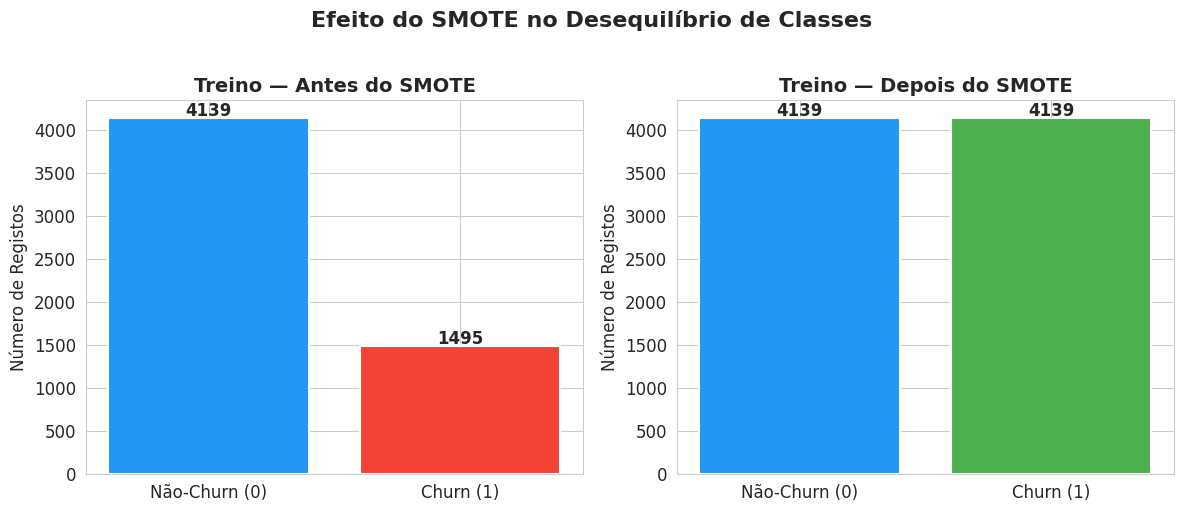


📌 Insight: SMOTE equilibrou as classes no treino — modelo não será enviesado para Não-Churn.
🔧 Próximo passo: definir métricas de avaliação.


In [5]:
# ─── Aplicação de SMOTE — Apenas no Treino ───────────────────
# Semana 8 | CRISP-DM: Modeling
# Justificação: SMOTE equilibra classes no treino sem contaminar o teste

print('Distribuição antes do SMOTE (treino):')
print(f'   Classe 0 (Não-churn): {(y_train == 0).sum()}')
print(f'   Classe 1 (Churn):     {(y_train == 1).sum()}')

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'\nDistribuição depois do SMOTE (treino):')
print(f'   Classe 0 (Não-churn): {(y_train_bal == 0).sum()}')
print(f'   Classe 1 (Churn):     {(y_train_bal == 1).sum()}')
print(f'\n✅ Resumo:')
print(f'   X_train_bal: {X_train_bal.shape}  |  X_test: {X_test.shape}')
print(f'   Distribuição teste (real, sem SMOTE): {dict(pd.Series(y_test).value_counts())}')

# Gráfico: antes vs. depois do SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts_before = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(['Não-Churn (0)', 'Churn (1)'], counts_before.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Treino — Antes do SMOTE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Registos')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

counts_after = pd.Series(y_train_bal).value_counts().sort_index()
axes[1].bar(['Não-Churn (0)', 'Churn (1)'], counts_after.values,
            color=['#2196F3', '#4CAF50'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Treino — Depois do SMOTE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Registos')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Efeito do SMOTE no Desequilíbrio de Classes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/smote_balanceamento.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n📌 Insight: SMOTE equilibrou as classes no treino — modelo não será enviesado para Não-Churn.')
print('🔧 Próximo passo: definir métricas de avaliação.')

### Justificação das Métricas de Avaliação

#### Por que não usar Accuracy?
Com ~73.5% de Não-churn, um modelo que prediz sempre **Não-churn** obteria 73.5% de *accuracy* sem detectar um único churner. Esta métrica é **enganadora** neste contexto.

#### Métricas adoptadas

| Métrica | Porquê usar |
|---------|-------------|
| **F1-Score (Churn)** ⭐ | Métrica principal — equilíbrio entre Precision e Recall na classe minoritária |
| **AUC-ROC** | Poder discriminativo geral — independente do threshold |
| **Recall (Churn)** | Quantos churners reais são identificados — falso negativo tem custo elevado |
| **Precision (Churn)** | Dos preditos como churn, quantos são reais |

**Objetivo SMART:** F1-Score ≥ 0.80 na classe Churn (definido em M1)

═══════════════════════════════════════════════════════
  PROBLEMA COM ACCURACY EM CLASSES DESEQUILIBRADAS
═══════════════════════════════════════════════════════
  Modelo ingénuo (sempre prediz Não-Churn):
    Accuracy:         73.46%  ← parece bom!
    Recall (churn):   0.00%  ← não detecta NENHUM churner
    F1-Score (churn): 0.00%  ← inútil para o negócio

  → Usamos F1-Score (Churn) como métrica principal.
  → Objetivo SMART: F1-Score ≥ 0.80 na classe Churn
═══════════════════════════════════════════════════════


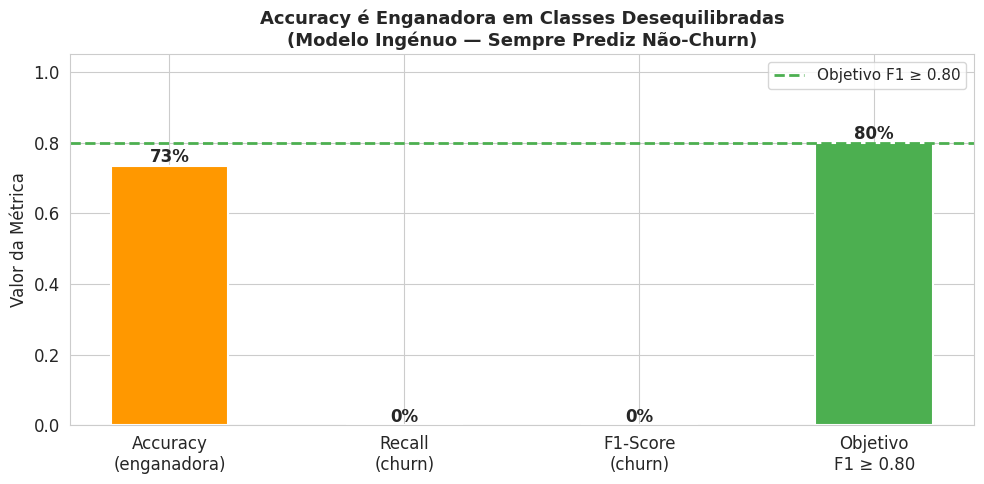


📌 Insight: 73.5% accuracy com 0% de churners detectados — accuracy é enganadora.
🔧 Próximo passo: Aula 16 — Regressão Logística como modelo baseline.


In [6]:
# ─── Visualização: Problema da Accuracy ──────────────────────
# Semana 8 | CRISP-DM: Modeling
# Justificação: demonstrar porque F1-Score é a métrica correcta

y_pred_naive   = np.zeros(len(y_test), dtype=int)
accuracy_naive = (y_pred_naive == y_test).mean()

print('═══════════════════════════════════════════════════════')
print('  PROBLEMA COM ACCURACY EM CLASSES DESEQUILIBRADAS')
print('═══════════════════════════════════════════════════════')
print(f'  Modelo ingénuo (sempre prediz Não-Churn):')
print(f'    Accuracy:         {accuracy_naive:.2%}  ← parece bom!')
print(f'    Recall (churn):   0.00%  ← não detecta NENHUM churner')
print(f'    F1-Score (churn): 0.00%  ← inútil para o negócio')
print()
print('  → Usamos F1-Score (Churn) como métrica principal.')
print('  → Objetivo SMART: F1-Score ≥ 0.80 na classe Churn')
print('═══════════════════════════════════════════════════════')

fig, ax = plt.subplots(figsize=(10, 5))
metricas = ['Accuracy\n(enganadora)', 'Recall\n(churn)', 'F1-Score\n(churn)', 'Objetivo\nF1 ≥ 0.80']
valores  = [accuracy_naive, 0.0, 0.0, 0.80]
cores    = ['#FF9800', '#F44336', '#F44336', '#4CAF50']

bars = ax.bar(metricas, valores, color=cores, edgecolor='white', linewidth=1.5, width=0.5)
ax.axhline(y=0.80, color='#4CAF50', linestyle='--', linewidth=2, label='Objetivo F1 ≥ 0.80')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor da Métrica')
ax.set_title('Accuracy é Enganadora em Classes Desequilibradas\n(Modelo Ingénuo — Sempre Prediz Não-Churn)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.0%}', ha='center', fontweight='bold', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('reports/figures/metricas_justificacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Insight: 73.5% accuracy com 0% de churners detectados — accuracy é enganadora.')
print('🔧 Próximo passo: Aula 16 — Regressão Logística como modelo baseline.')